# 🧪 EXERCISE: Single-Session Behavioural Analysis

> **Instructions:** This notebook has intentional gaps — paths, function bodies, plot code, and statistical calls that you must complete. Look for `# TODO` and `???` markers. Run cells in order once you've filled in each blank.

## Learning objectives

- Set file paths and participant identifiers for a single-session analysis
- Implement derived columns in a data-loading function (axis labels, eccentricity, data types)
- Compute accuracy and RT quartile metrics from a pandas DataFrame
- Add rolling windows and a linear regression trend to a learning-curve plot
- Run and interpret Kruskal-Wallis and Spearman correlation statistical tests

---

# VISION Task — Single Session: Behavioural Performance & Statistical Analysis

Behavioural performance analysis for **one participant, one recording session** of the **VISION arrow-key task**.

Processes:
- Trial-level performance data (accuracy, reaction time, errors)
- Within-session statistical summaries
- Correlations with eye-movement metrics

> For multi-participant group analysis, see `VISION_group_analysis.ipynb`.


---
## 0 Setup

In [1]:
# SCOPE: one participant × one recording session

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import glob
import os
import re

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── TODO 1: Set your data paths and participant details ───────────────────
# Replace each '???' with the correct value.
# DATA_DIR       → folder that contains your PsychoPy CSV files
# FOCAL_PARTICIPANT → participant label used in the filenames
# PARTICIPANT_SESSION → session number as a 3-character string (e.g. '001', '002')

DATA_DIR           = Path('???')   # e.g. Path('/Users/you/recordings/data')
FOCAL_PARTICIPANT  = '???'         # e.g. 'P_04'
PARTICIPANT_SESSION = '???'        # e.g. '002'
GAZE_METRICS_CSV   = f'/Users/mikolajturczyniak/recordings/{FOCAL_PARTICIPANT}_VISION_task_gaze_metrics_{PARTICIPANT_SESSION}.csv'

# Task constants (must match VISION_task.py)
POSITION_STEP_DEG = 4.5
POSITIONS_DEG     = [POSITION_STEP_DEG * i for i in range(1, 8)]
AXES_DEG          = [0, 45, 135]
AXIS_LABELS_MAP   = {0: 'Horizontal', 45: 'Diagonal BL→TR', 135: 'Diagonal TL→BR'}
MIN_ACCURACY      = 0.75

print(f'Data directory    : {DATA_DIR}')
print(f'Focal participant : {FOCAL_PARTICIPANT}')
print(f'Available CSVs    : {sorted(glob.glob(str(DATA_DIR / "*VISION_task*.csv")))}')

---
## 1 Load & Preprocess Data

In [3]:
_REQUIRED_COLS = {'trial_num', 'axis_deg', 'position_num', 'side', 'is_correct'}

def load_participant(path):
    """
    Load a single participant VISION_task CSV.
    Returns cleaned DataFrame with derived columns, or None if the file
    is not a VISION_task output (missing required columns).
    """
    df = pd.read_csv(path, encoding='utf-8-sig')
    df = df.dropna(axis=1, how='all')

    missing = _REQUIRED_COLS - set(df.columns)
    if missing:
        print(f'  [skip] {Path(path).name} — missing columns: {missing}')
        return None

    df = df.dropna(subset=['trial_num']).copy()
    df['trial_num'] = df['trial_num'].astype(int)

    # ── TODO 2a: Map axis_deg (integer) to a human-readable label ────────
    # Use AXIS_LABELS_MAP: {0: 'Horizontal', 45: 'Diagonal BL→TR', 135: 'Diagonal TL→BR'}
    # Hint: pd.to_numeric(...).map(dict)
    df['axis_label'] = ???   # replace with your mapping expression

    # ── TODO 2b: Compute eccentricity in degrees ──────────────────────────
    # position_num is 1-7; POSITIONS_DEG is a list where index 0 = pos 1.
    # Convert position_num to float, then look up POSITIONS_DEG[int(p)-1].
    df['eccentricity_deg'] = (pd.to_numeric(df['position_num'], errors='coerce')
                               .apply(lambda p: ???))  # TODO: fill in the lookup

    # ── TODO 2c: Cast is_correct to integer (fill NaN with 0) ────────────
    # Hint: pd.to_numeric(..., errors='coerce').fillna(0).astype(int)
    df['is_correct'] = ???   # replace with correct cast

    if 'response_time_s' in df.columns:
        df['rt'] = pd.to_numeric(df['response_time_s'], errors='coerce')
    else:
        df['rt'] = np.nan

    df['participant'] = Path(path).stem.split('_')[0]
    return df


def load_all_participants(data_dir):
    paths = sorted(glob.glob(str(Path(data_dir) / '*VISION_task*.csv')))
    paths = [p for p in paths if 'gaze_metrics' not in Path(p).name]
    if not paths:
        raise FileNotFoundError(f'No VISION_task behavioral CSVs found in {data_dir}')
    dfs = [load_participant(p) for p in paths]
    dfs = [d for d in dfs if d is not None and len(d) > 0]
    if not dfs:
        raise ValueError('All CSVs in data_dir were skipped (wrong format).')
    return pd.concat(dfs, ignore_index=True)


# ── Load focal participant ─────────────────────────────────────────────────
focal_paths = sorted([
    p for p in glob.glob(str(DATA_DIR / f'{FOCAL_PARTICIPANT}*VISION_task*.csv'))
    if 'gaze_metrics' not in Path(p).name
])
if not focal_paths:
    focal_paths = sorted([p for p in glob.glob('*VISION_task*.csv')
                          if 'gaze_metrics' not in Path(p).name])

df = None
for fp in focal_paths:
    candidate = load_participant(fp)
    if candidate is not None and len(candidate) > 0:
        df = candidate
        print(f'Loaded : {fp}')
        print(f'Trials : {len(df)}')
        break

if df is None:
    print('No valid VISION_task CSV found. Check that DATA_DIR and FOCAL_PARTICIPANT are correct.')

df.head()

---
## 2 Data Quality Check

In [4]:
def quality_report(df, label='Dataset'):
    n_total   = len(df)
    n_correct = df['is_correct'].sum()
    accuracy  = n_correct / n_total if n_total else 0
    rt        = df.loc[df['is_correct'] == 1, 'rt'].dropna()
    rt_mean, rt_sd = rt.mean(), rt.std()
    rt_outliers = int((rt > rt_mean + 2.5 * rt_sd).sum())
    rt_very_fast = int((rt < 0.1).sum())

    print(f'── {label} ──────────────────────────────')
    print(f'  Total trials    : {n_total}')
    print(f'  Correct         : {n_correct} ({accuracy:.1%})')
    print(f'  Incorrect       : {n_total - n_correct}')
    print(f'  Pass criterion  : {"✓ ≥75%" if accuracy >= MIN_ACCURACY else "✗ <75%"}')
    if len(rt):
        print(f'  RT mean ± SD    : {rt_mean:.3f} ± {rt_sd:.3f} s')
        print(f'  RT range        : [{rt.min():.3f}, {rt.max():.3f}] s')
        print(f'  RT outliers (>mean+2.5SD): {rt_outliers}')
        print(f'  Very fast (<100ms)        : {rt_very_fast}')
    missing_rt = df['rt'].isna().sum()
    if missing_rt:
        print(f'  Missing RT      : {missing_rt}')
    # Shape balance
    if 'shape' in df.columns:
        shape_counts = df['shape'].value_counts()
        print(f'  Shape balance   : {shape_counts.to_dict()}')
    print()

quality_report(df, label=FOCAL_PARTICIPANT)

── P_04 ──────────────────────────────
  Total trials    : 42
  Correct         : 42 (100.0%)
  Incorrect       : 0
  Pass criterion  : ✓ ≥75%
  RT mean ± SD    : 0.747 ± 0.168 s
  RT range        : [0.566, 1.648] s
  RT outliers (>mean+2.5SD): 1
  Very fast (<100ms)        : 0
  Shape balance   : {'circle': 22, 'triangle': 20}



---
## 3 Core Performance Metrics

Matching primary measures from Aloufi et al. (2021):
- **Accuracy** — proportion correct (criterion ≥ 75%)
- **RT** — time from shape onset to key press
- **Shape identification** — circle vs triangle discrimination

In [5]:
def core_metrics(df):
    correct   = df[df['is_correct'] == 1]
    incorrect = df[df['is_correct'] == 0]
    rt        = correct['rt'].dropna()
    rt_err    = incorrect['rt'].dropna()

    # ── TODO 3a: Compute overall accuracy ────────────────────────────────
    # accuracy = number of correct trials / total trials
    # Remember: guard against division by zero with:  ... if len(df) else 0
    accuracy = ???   # replace with the correct expression

    # ── TODO 3b: Compute RT quartiles (25th and 75th percentile) ─────────
    # Hint: use .quantile(0.25) and .quantile(0.75) on the rt Series
    rt_q25 = ???
    rt_q75 = ???

    return {
        'n_trials'      : len(df),
        'n_correct'     : len(correct),
        'n_incorrect'   : len(incorrect),
        'accuracy'      : accuracy,
        'pass_criterion': accuracy >= MIN_ACCURACY if len(df) else False,
        'rt_mean'       : rt.mean(),
        'rt_sd'         : rt.std(),
        'rt_median'     : rt.median(),
        'rt_q25'        : rt_q25,
        'rt_q75'        : rt_q75,
        'rt_min'        : rt.min(),
        'rt_max'        : rt.max(),
        'rt_error_mean' : rt_err.mean(),
        'rt_error_sd'   : rt_err.std(),
    }


m = core_metrics(df)
print('='*55)
print(f'  Participant      : {FOCAL_PARTICIPANT}')
print(f'  Trials           : {m["n_trials"]}')
print(f'  Accuracy         : {m["accuracy"]:.1%}  {"✓" if m["pass_criterion"] else "✗"} (criterion ≥75%)')
print(f'  Correct / Wrong  : {m["n_correct"]} / {m["n_incorrect"]}')
print('  ─ Response Time (correct trials) ─────────────')
print(f'  RT mean ± SD     : {m["rt_mean"]:.3f} ± {m["rt_sd"]:.3f} s')
print(f'  RT median        : {m["rt_median"]:.3f} s')
print(f'  RT IQR           : [{m["rt_q25"]:.3f}, {m["rt_q75"]:.3f}] s')
print(f'  RT range         : [{m["rt_min"]:.3f}, {m["rt_max"]:.3f}] s')
print('='*55)

---
## 4 RT Distribution

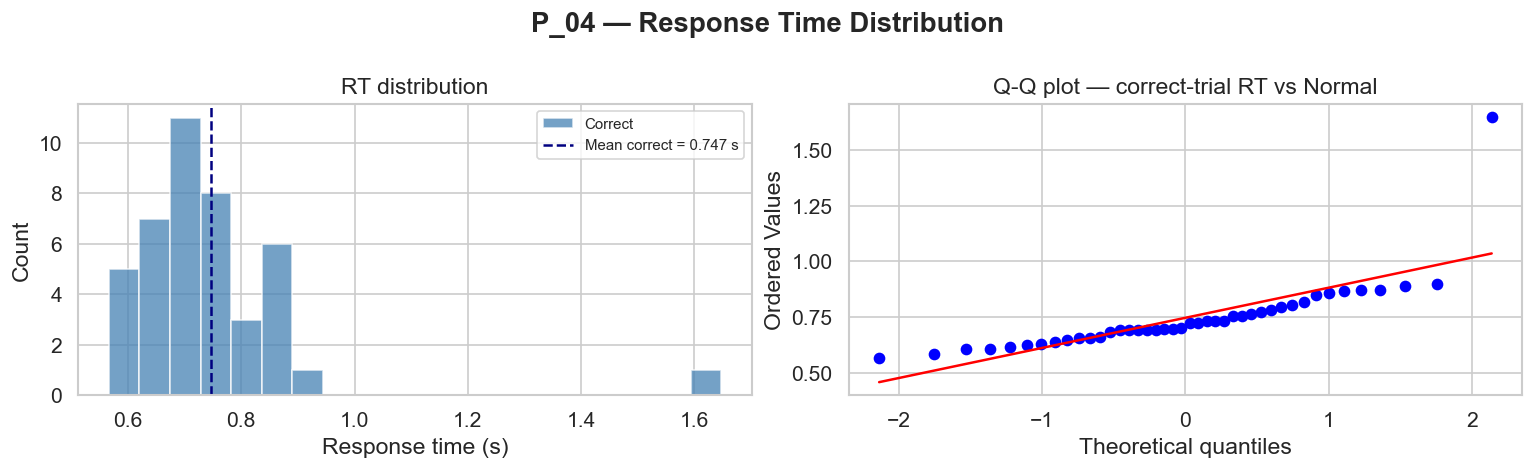

In [6]:
correct = df[df['is_correct'] == 1].copy()
incorrect = df[df['is_correct'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(correct['rt'].dropna(), bins=20, color='steelblue', alpha=0.75,
        edgecolor='white', label='Correct')
if len(incorrect) > 0:
    ax.hist(incorrect['rt'].dropna(), bins=20, color='salmon', alpha=0.65,
            edgecolor='white', label='Incorrect')
ax.axvline(correct['rt'].mean(), color='navy', lw=1.5, ls='--',
           label=f'Mean correct = {correct["rt"].mean():.3f} s')
ax.set_xlabel('Response time (s)')
ax.set_ylabel('Count')
ax.set_title('RT distribution')
ax.legend(fontsize=9)

---
## 5 Learning Curve (Within Session)

In [7]:
WIN = 8   # rolling window size (trials)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: RT over trials ──────────────────────────────────────────────
ax = axes[0]
c = df.copy()

# ── TODO 4a: Compute a rolling mean of RT ────────────────────────────────
# Use .rolling(window, min_periods=3, center=True).mean() on the 'rt' column.
# Store the result as a new column 'rt_roll'.
c['rt_roll'] = ???   # replace with rolling mean expression

ax.scatter(c['trial_num'], c['rt'], alpha=0.3, s=20, color='steelblue',
           label='Individual trial')
ax.plot(c['trial_num'], c['rt_roll'], lw=2, color='navy',
        label=f'Rolling mean (n={WIN})')

# ── TODO 4b: Fit and plot a linear trend line ─────────────────────────────
# Use stats.linregress(x, y) where x = trial_num and y = rt.
# Then plot the fitted line as a red dashed line.
# The label should show the slope (s/trial) and p-value.
valid_rt = c.dropna(subset=['rt'])
if len(valid_rt) > 3:
    # slope, intercept, r, p, _ = ???   # TODO: fill in linregress call
    # x_fit = valid_rt['trial_num'].values
    # ax.plot(???)                      # TODO: plot intercept + slope*x_fit
    pass  # remove this line once you fill in the code above

ax.set_xlabel('Trial number')
ax.set_ylabel('RT (s)')
ax.set_title('Response time over trials')
ax.legend(fontsize=9)

# ── Panel B: rolling accuracy ────────────────────────────────────────────
ax = axes[1]

# ── TODO 4c: Compute rolling accuracy ────────────────────────────────────
# Same pattern as 4a but for the 'is_correct' column, multiplied by 100.
c['acc_roll'] = ???   # replace with rolling accuracy expression (×100 for %)

ax.plot(c['trial_num'], c['acc_roll'], lw=2, color='seagreen',
        label=f'Rolling accuracy (n={WIN})')
ax.axhline(MIN_ACCURACY * 100, color='red', ls='--', lw=1.2,
           label=f'Criterion {MIN_ACCURACY*100:.0f}%')
ax.scatter(c['trial_num'], c['is_correct'] * 100, alpha=0.15, s=10, color='seagreen')
ax.set_xlabel('Trial number')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(-5, 105)
ax.set_title('Rolling accuracy over trials')
ax.legend(fontsize=9)

plt.suptitle(f'{FOCAL_PARTICIPANT} — Learning Curve', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 Shape Identification: Circle vs Triangle

Checks whether the patient had difficulty identifying one shape over the other — clinically relevant for visual agnosia or hemifield neglect.

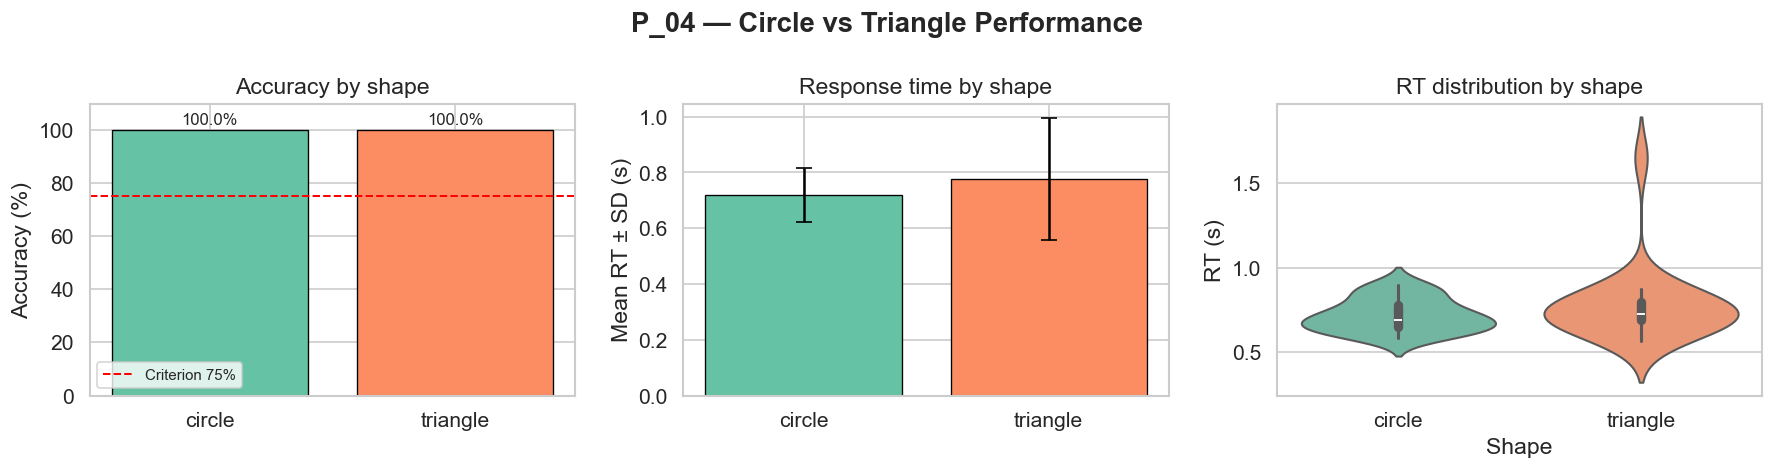

Chi-square test (accuracy circle vs triangle): χ²=0.000, df=0, p=1.0000
Mann-Whitney RT (circle vs triangle):   U=180, p=0.3198
  Circle RT   : 0.720 ± 0.097 s
  Triangle RT : 0.777 ± 0.220 s


In [8]:
if 'shape' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    shape_order = ['circle', 'triangle']
    shape_stats = df.groupby('shape').agg(
        n=('is_correct', 'count'),
        accuracy=('is_correct', 'mean'),
        rt_mean=('rt', 'mean'),
        rt_sd=('rt', 'std'),
    ).reindex(shape_order)

    # Accuracy by shape
    ax = axes[0]
    bars = ax.bar(shape_order, shape_stats['accuracy'] * 100,
                  color=sns.color_palette('Set2', 2), edgecolor='k', linewidth=0.8)
    ax.axhline(MIN_ACCURACY * 100, color='red', ls='--', lw=1.2,
               label=f'Criterion {MIN_ACCURACY*100:.0f}%')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy by shape')
    ax.legend(fontsize=9)
    for bar, acc in zip(bars, shape_stats['accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1%}', ha='center', va='bottom', fontsize=10)

    # RT by shape
    ax = axes[1]
    correct_shape = df[df['is_correct']==1]
    ax.bar(shape_order, shape_stats['rt_mean'],
           yerr=shape_stats['rt_sd'], capsize=5,
           color=sns.color_palette('Set2', 2), edgecolor='k', linewidth=0.8)
    ax.set_ylabel('Mean RT ± SD (s)')
    ax.set_title('Response time by shape')

    # RT violin by shape
    ax = axes[2]
    sns.violinplot(data=df[df['is_correct']==1], x='shape', y='rt',
                   order=shape_order, palette='Set2', ax=ax, inner='box')
    ax.set_xlabel('Shape')
    ax.set_ylabel('RT (s)')
    ax.set_title('RT distribution by shape')

    plt.suptitle(f'{FOCAL_PARTICIPANT} — Circle vs Triangle Performance', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Chi-square: accuracy difference
    if len(shape_stats) == 2 and all(shape_stats['n'] > 0):
        ct = pd.crosstab(df['shape'], df['is_correct'])
        chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
        print(f'Chi-square test (accuracy circle vs triangle): χ²={chi2:.3f}, df={dof}, p={p_chi:.4f}')

    # Mann-Whitney: RT difference
    circle_rt   = df[(df['shape']=='circle')   & (df['is_correct']==1)]['rt'].dropna()
    triangle_rt = df[(df['shape']=='triangle') & (df['is_correct']==1)]['rt'].dropna()
    if len(circle_rt) > 1 and len(triangle_rt) > 1:
        u, p_mw = stats.mannwhitneyu(circle_rt, triangle_rt, alternative='two-sided')
        print(f'Mann-Whitney RT (circle vs triangle):   U={u:.0f}, p={p_mw:.4f}')
        print(f'  Circle RT   : {circle_rt.mean():.3f} ± {circle_rt.std():.3f} s')
        print(f'  Triangle RT : {triangle_rt.mean():.3f} ± {triangle_rt.std():.3f} s')
else:
    print('No shape column found in data.')

---

## 6.5 Interpreting Performance by Task Axis

Now let's examine whether performance varied depending on the direction (axis) and spatial location of the targets. Some participants show directional biases or field defects that only become apparent when we break down accuracy by stimulus position.

---
## 7 Breakdown by Axis, Hemifield, and Eccentricity

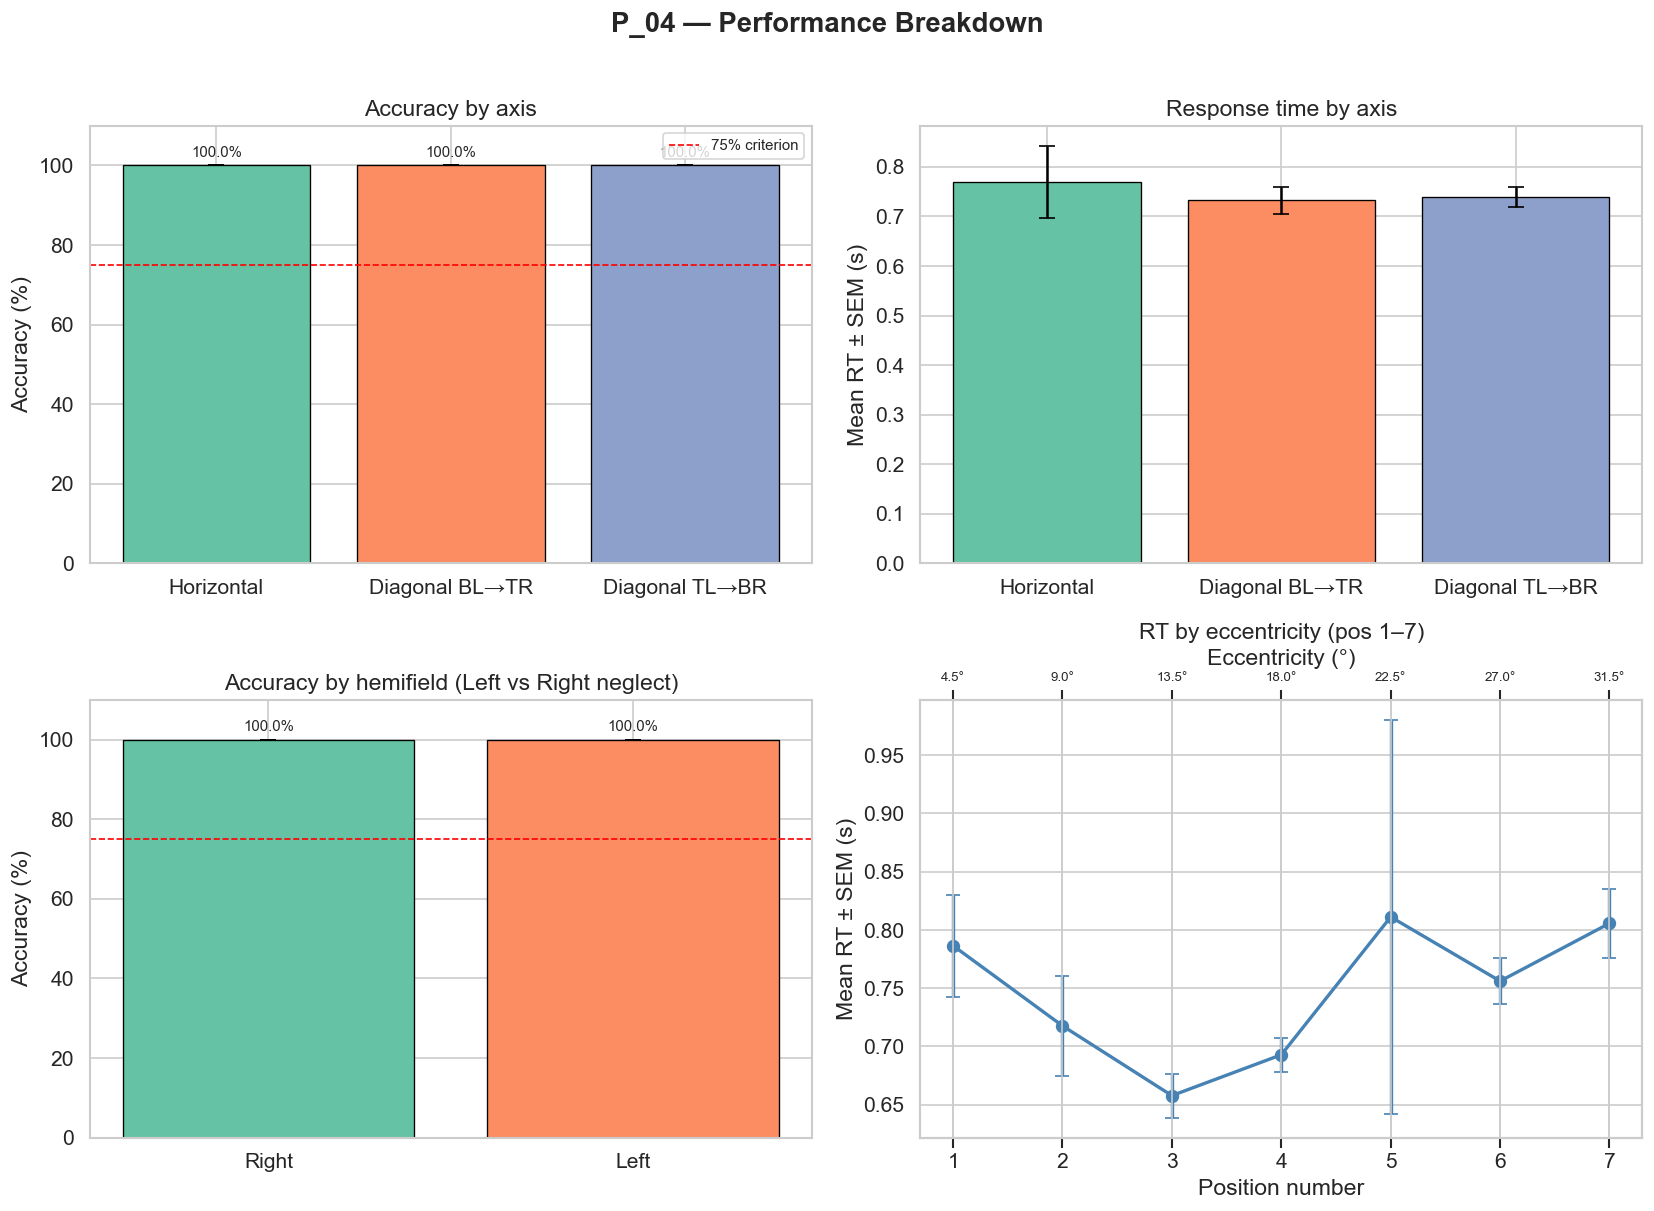

In [9]:
correct = df[df['is_correct'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axis_order = ['Horizontal', 'Diagonal BL→TR', 'Diagonal TL→BR']

# ── Panel A: accuracy by axis ─────────────────────────────────────────────────
ax = axes[0, 0]
axis_acc = df.groupby('axis_label').agg(
    accuracy=('is_correct', 'mean'),
    n=('is_correct', 'count')
).reindex(axis_order)
ci95 = 1.96 * np.sqrt(axis_acc['accuracy'] * (1 - axis_acc['accuracy']) / axis_acc['n'])
bars = ax.bar(axis_order, axis_acc['accuracy']*100, yerr=ci95*100, capsize=5,
              color=sns.color_palette('Set2', 3), edgecolor='k', linewidth=0.8)
ax.axhline(MIN_ACCURACY * 100, color='red', ls='--', lw=1, label='75% criterion')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by axis')
ax.legend(fontsize=9)
for bar, val in zip(bars, axis_acc['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# ── Panel B: RT by axis ───────────────────────────────────────────────────────
ax = axes[0, 1]
rt_axis = correct.groupby('axis_label')['rt'].agg(['mean','sem']).reindex(axis_order)
ax.bar(axis_order, rt_axis['mean'], yerr=rt_axis['sem'], capsize=5,
       color=sns.color_palette('Set2', 3), edgecolor='k', linewidth=0.8)
ax.set_ylabel('Mean RT ± SEM (s)')
ax.set_title('Response time by axis')

# ── Panel C: accuracy by hemifield ───────────────────────────────────────────
ax = axes[1, 0]
hemi_order = ['Right', 'Left']
if 'hemifield' not in df.columns:
    df['hemifield'] = df['side'].map({'R': 'Right', 'L': 'Left'})
    correct['hemifield'] = correct['side'].map({'R': 'Right', 'L': 'Left'})
hemi_acc = df.groupby('hemifield').agg(
    accuracy=('is_correct', 'mean'),
    n=('is_correct', 'count')
).reindex(hemi_order)
ci_h = 1.96 * np.sqrt(hemi_acc['accuracy'] * (1 - hemi_acc['accuracy']) / hemi_acc['n'])
bars = ax.bar(hemi_order, hemi_acc['accuracy']*100, yerr=ci_h*100, capsize=5,
              color=sns.color_palette('Set2', 2), edgecolor='k', linewidth=0.8)
ax.axhline(MIN_ACCURACY * 100, color='red', ls='--', lw=1)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by hemifield (Left vs Right neglect)')
for bar, val in zip(bars, hemi_acc['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# ── Panel D: RT by eccentricity ───────────────────────────────────────────────
ax = axes[1, 1]
ecc_rt = correct.groupby('position_num')['rt'].agg(['mean','sem']).reset_index()
ax.errorbar(ecc_rt['position_num'], ecc_rt['mean'], yerr=ecc_rt['sem'],
            marker='o', markersize=7, lw=2, capsize=4, color='steelblue')
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ecc_rt['position_num'])
ax2.set_xticklabels([f'{POSITIONS_DEG[int(p)-1]:.1f}°' for p in ecc_rt['position_num']], fontsize=8)
ax2.set_xlabel('Eccentricity (°)')
ax.set_xlabel('Position number')
ax.set_ylabel('Mean RT ± SEM (s)')
ax.set_title('RT by eccentricity (pos 1–7)')

plt.suptitle(f'{FOCAL_PARTICIPANT} — Performance Breakdown', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8 Heatmap — Accuracy & RT by Position × Axis

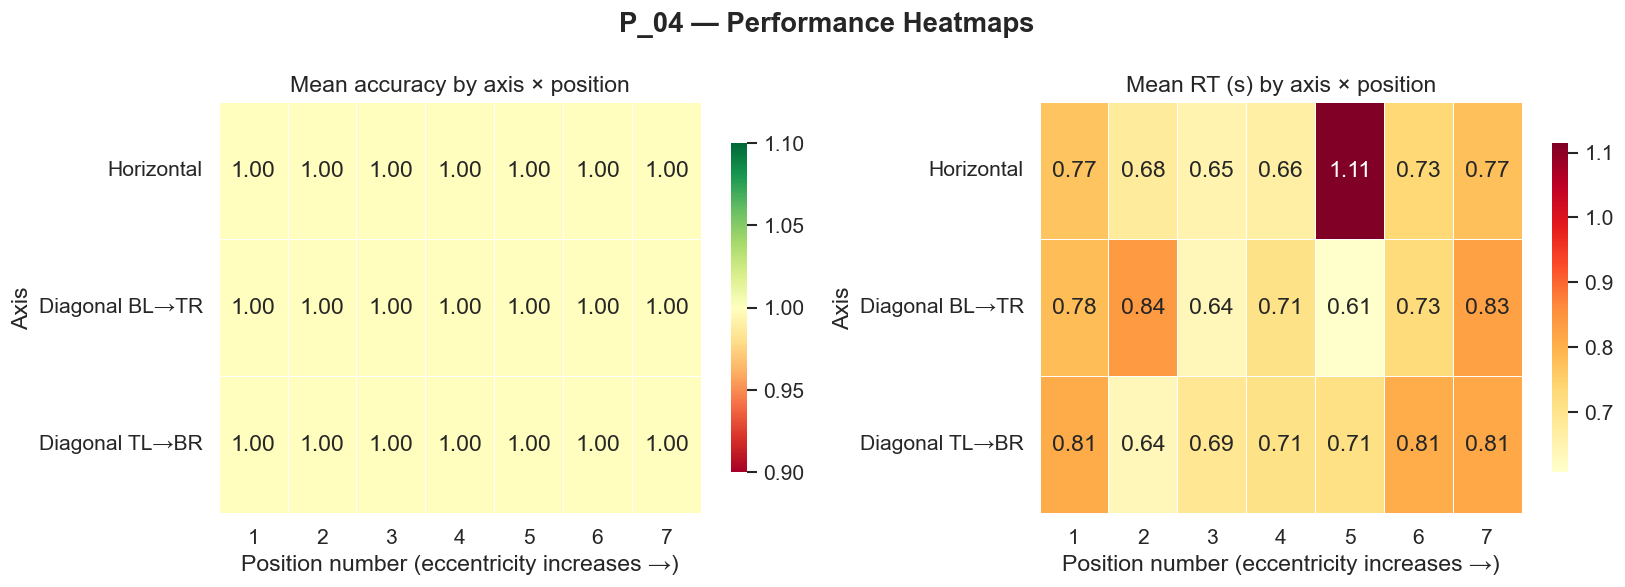

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label, cmap) in zip(
    axes,
    [('is_correct', 'Mean accuracy', 'RdYlGn'),
     ('rt',         'Mean RT (s)',   'YlOrRd')]
):
    src  = df if metric == 'is_correct' else df[df['is_correct']==1]
    pivot = src.pivot_table(
        index='axis_label', columns='position_num',
        values=metric, aggfunc='mean'
    ).reindex(['Horizontal', 'Diagonal BL→TR', 'Diagonal TL→BR'])
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap=cmap,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Position number (eccentricity increases →)')
    ax.set_ylabel('Axis')
    ax.set_title(f'{label} by axis × position')

plt.suptitle(f'{FOCAL_PARTICIPANT} — Performance Heatmaps', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9 Spatial Accuracy Map

Visualises accuracy at each target position — important for detecting systematic hemifield or eccentricity deficits.

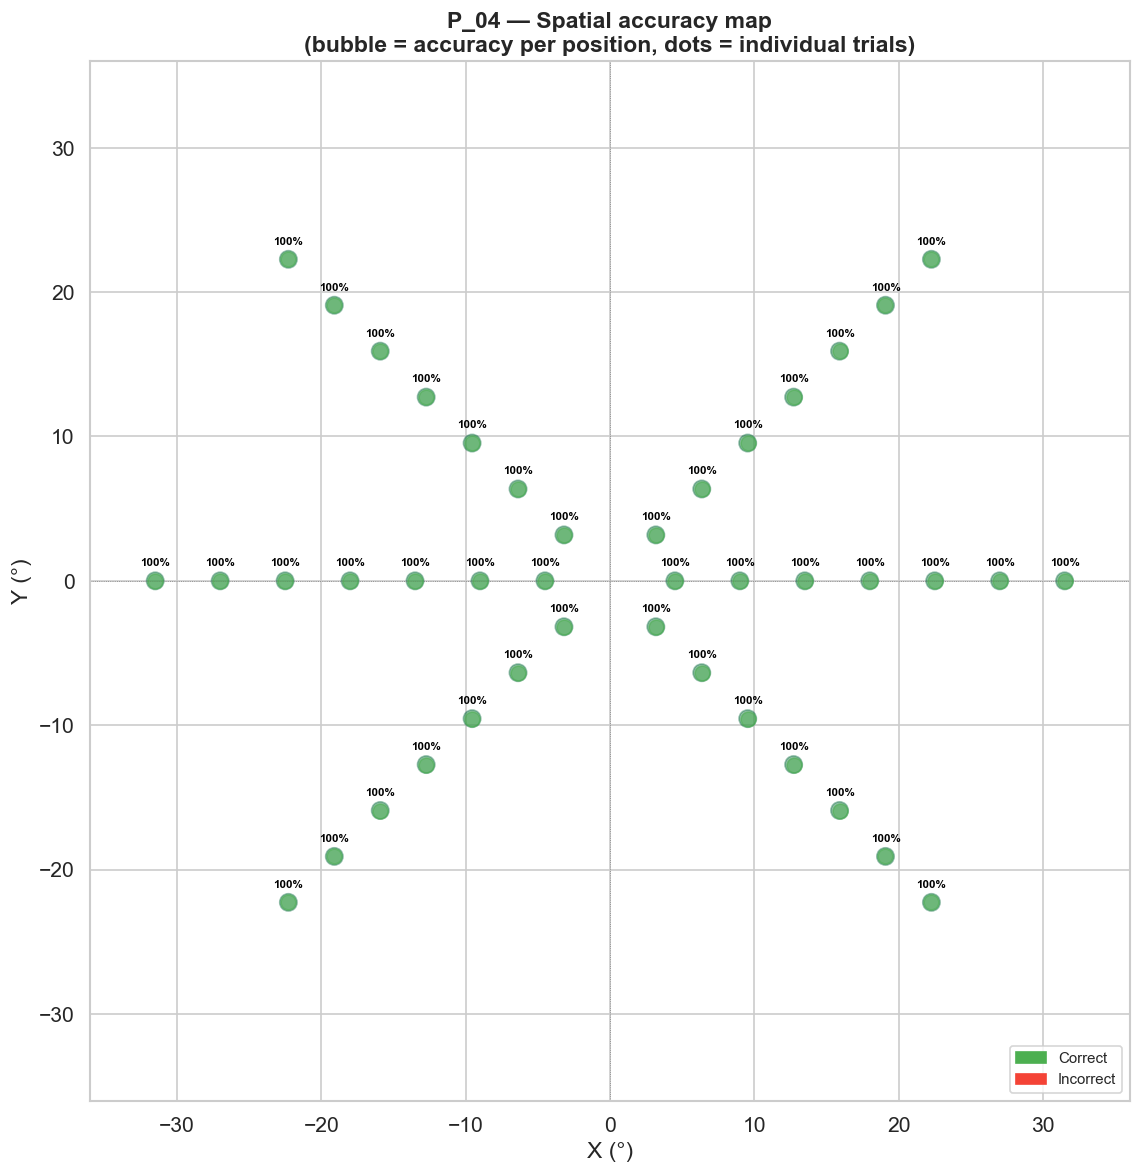

In [11]:
def get_xy(axis_deg, pos_num, side_char, step=POSITION_STEP_DEG):
    s    = 1 if side_char == 'R' else -1
    ecc  = step * pos_num
    arad = np.radians(axis_deg)
    return s * ecc * np.cos(arad), s * ecc * np.sin(arad)

fig, ax = plt.subplots(figsize=(10, 10))

PALETTE_CORR = {1: '#4CAF50', 0: '#F44336'}

for _, row in df.iterrows():
    if pd.isna(row.get('axis_deg')) or pd.isna(row.get('position_num')):
        continue
    x, y = get_xy(int(row['axis_deg']), int(row['position_num']), row['side'])
    color = PALETTE_CORR.get(row['is_correct'], 'grey')
    ax.scatter(x, y, s=80, color=color, alpha=0.55, zorder=3)

# Overlay accuracy per position
pos_acc = df.groupby(['axis_deg', 'position_num', 'side']).agg(
    acc=('is_correct', 'mean'), n=('is_correct', 'count')
).reset_index()

for _, row in pos_acc.iterrows():
    x, y = get_xy(int(row['axis_deg']), int(row['position_num']), row['side'])
    color = plt.cm.RdYlGn(row['acc'])
    circ  = plt.Circle((x, y), radius=0.6, color=color, alpha=0.4, zorder=2)
    ax.add_patch(circ)
    ax.text(x, y + 0.9, f'{row["acc"]:.0%}', ha='center', va='bottom',
            fontsize=7, color='black', fontweight='bold')

ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')
ax.set_aspect('equal')
ax.set_xlim(-36, 36)
ax.set_ylim(-36, 36)
ax.set_xlabel('X (°)')
ax.set_ylabel('Y (°)')

correct_patch = mpatches.Patch(color='#4CAF50', label='Correct')
wrong_patch   = mpatches.Patch(color='#F44336', label='Incorrect')
ax.legend(handles=[correct_patch, wrong_patch], loc='lower right', fontsize=9)

ax.set_title(f'{FOCAL_PARTICIPANT} — Spatial accuracy map\n'
             f'(bubble = accuracy per position, dots = individual trials)',
             fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10 Statistical Tests - for trials

In [12]:
correct = df[df['is_correct'] == 1].copy()
rt = correct['rt'].dropna()

print('='*60)
print(f'STATISTICAL TESTS — {FOCAL_PARTICIPANT}')
print('='*60)

# 1. Normality (complete — no TODO)
if len(rt) >= 8:
    stat, p = stats.shapiro(rt)
    print(f'\n1. Normality of RT (Shapiro-Wilk): W={stat:.3f}, p={p:.4f}')
    print(f'   RT is {"" if p > 0.05 else "NOT "}normally distributed (α=0.05)')

# 2. Binomial test (complete — no TODO)
n = len(df); k = df['is_correct'].sum()
try:
    p_binom = stats.binomtest(k, n, p=MIN_ACCURACY, alternative='greater').pvalue
except AttributeError:
    p_binom = stats.binom_test(k, n, p=MIN_ACCURACY, alternative='greater')
print(f'\n2. Binomial test (accuracy > 75%): k={k}/{n}, p={p_binom:.4f}')
print(f'   Accuracy criterion {"MET" if p_binom < 0.05 else "NOT MET"} (α=0.05)')

# ── TODO 5a: Kruskal-Wallis test — RT across the three axes ──────────────
# Steps:
#   1. Build a list called groups_axis — one array of RT values per axis.
#      Use: correct[correct['axis_label'] == ax]['rt'].dropna().values
#      Loop over ['Horizontal', 'Diagonal BL→TR', 'Diagonal TL→BR']
#   2. Keep only groups with ≥ 3 values.
#   3. Call stats.kruskal(*groups_axis) to get (H, p_kw).
#   4. Print the result.
print('\n3. Kruskal-Wallis RT across axes:')
# groups_axis = [???]           # TODO: build group list
# groups_axis = [g for g in groups_axis if len(g) >= 3]
# if len(groups_axis) >= 2:
#     H, p_kw = ???              # TODO: run test
#     print(f'   H={H:.3f}, p={p_kw:.4f} → {"significant" if p_kw < 0.05 else "not significant"}')

# 4. Mann-Whitney: RT Right vs Left hemifield (complete — no TODO)
if 'hemifield' not in correct.columns:
    correct['hemifield'] = correct['side'].map({'R': 'Right', 'L': 'Left'})
r_rt = correct[correct['hemifield']=='Right']['rt'].dropna()
l_rt = correct[correct['hemifield']=='Left']['rt'].dropna()
if len(r_rt) > 1 and len(l_rt) > 1:
    U, p_mw = stats.mannwhitneyu(r_rt, l_rt, alternative='two-sided')
    r_eff = 1 - (2*U) / (len(r_rt) * len(l_rt))
    print(f'\n4. Mann-Whitney RT (Right vs Left hemifield):')
    print(f'   U={U:.0f}, p={p_mw:.4f}, r={r_eff:.3f}')
    print(f'   Right: {r_rt.mean():.3f} ± {r_rt.std():.3f} s')
    print(f'   Left : {l_rt.mean():.3f} ± {l_rt.std():.3f} s')

# ── TODO 5b: Spearman correlation — RT vs eccentricity ───────────────────
# Steps:
#   1. Create valid_ecc by dropping NaN from correct[['eccentricity_deg', 'rt']].
#   2. Call stats.spearmanr(x, y) to get (r_sp, p_sp).
#   3. Print the ρ value, p-value, and whether it is significant.
print('\n5. Spearman correlation RT vs eccentricity:')
# valid_ecc = ???                # TODO: drop NaN rows
# if len(valid_ecc) > 5:
#     r_sp, p_sp = ???           # TODO: run spearmanr
#     print(f'   ρ={r_sp:.3f}, p={p_sp:.4f}')
#     print(f'   {"Significant" if p_sp < 0.05 else "No significant"} effect of eccentricity (α=0.05)')

# 6. Chi-square: accuracy Right vs Left (complete — no TODO)
if 'hemifield' not in df.columns:
    df['hemifield'] = df['side'].map({'R': 'Right', 'L': 'Left'})
ct_hemi = pd.crosstab(df['hemifield'], df['is_correct'])
if ct_hemi.shape == (2, 2):
    chi2_h, p_chi_h, dof_h, _ = stats.chi2_contingency(ct_hemi)
    print(f'\n6. Chi-square accuracy Right vs Left: χ²={chi2_h:.3f}, p={p_chi_h:.4f}')

# 7. Linear trend: RT over trial number (complete — no TODO)
valid_all = df.dropna(subset=['rt'])
if len(valid_all) > 5:
    slope_l, _, r_l, p_l, _ = stats.linregress(valid_all['trial_num'], valid_all['rt'])
    print(f'\n7. Linear trend RT vs trial number (learning):')
    print(f'   slope={slope_l:.5f} s/trial, r={r_l:.3f}, p={p_l:.4f}')
    direction = 'faster (learning)' if slope_l < 0 else 'slower (fatigue)'
    print(f'   Trend: {direction} — {"significant" if p_l < 0.05 else "not significant"} (α=0.05)')

print('\n' + '='*60)

---
## 11 Full Summary Table

In [13]:
correct = df[df['is_correct'] == 1].copy()
if 'hemifield' not in df.columns:
    df['hemifield'] = df['side'].map({'R': 'Right', 'L': 'Left'})
if 'hemifield' not in correct.columns:
    correct['hemifield'] = correct['side'].map({'R': 'Right', 'L': 'Left'})

def agg_perf(g):
    rt  = g['rt'].dropna()
    acc = g['is_correct'].mean()
    return pd.Series({
        'n_trials'    : len(g),
        'accuracy'    : acc,
        'rt_mean'     : rt.mean(),
        'rt_sd'       : rt.std(),
        'rt_median'   : rt.median(),
    })

print('── By axis ─────────────────────────────────────────────')
axis_tbl = df.groupby('axis_label').apply(agg_perf).reindex(
    ['Horizontal', 'Diagonal BL→TR', 'Diagonal TL→BR'])
print(axis_tbl.round(3).to_string())

print('\n── By hemifield ────────────────────────────────────────')
hemi_tbl = df.groupby('hemifield').apply(agg_perf)
print(hemi_tbl.round(3).to_string())

print('\n── By position (eccentricity) ──────────────────────────')
pos_tbl = df.groupby('position_num').apply(agg_perf)
pos_tbl.insert(0, 'eccentricity_deg',
               [POSITIONS_DEG[int(p)-1] for p in pos_tbl.index])
print(pos_tbl.round(3).to_string())

if 'shape' in df.columns:
    print('\n── By shape ────────────────────────────────────────────')
    shape_tbl = df.groupby('shape').apply(agg_perf)
    print(shape_tbl.round(3).to_string())

── By axis ─────────────────────────────────────────────
                n_trials  accuracy  rt_mean  rt_sd  rt_median
axis_label                                                   
Horizontal          14.0       1.0    0.769  0.269      0.695
Diagonal BL→TR      14.0       1.0    0.732  0.100      0.711
Diagonal TL→BR      14.0       1.0    0.739  0.075      0.732

── By hemifield ────────────────────────────────────────
           n_trials  accuracy  rt_mean  rt_sd  rt_median
hemifield                                               
Left           21.0       1.0    0.764  0.211      0.722
Right          21.0       1.0    0.730  0.112      0.700

── By position (eccentricity) ──────────────────────────
              eccentricity_deg  n_trials  accuracy  rt_mean  rt_sd  rt_median
position_num                                                                 
1                          4.5       6.0       1.0    0.786  0.107      0.810
2                          9.0       6.0       1.0    0

---
## 13 Gaze–Behaviour Integration

Merges with gaze metrics (from `VISION_task_gaze_metrics.ipynb`) to correlate eye-movement features with response time and accuracy.

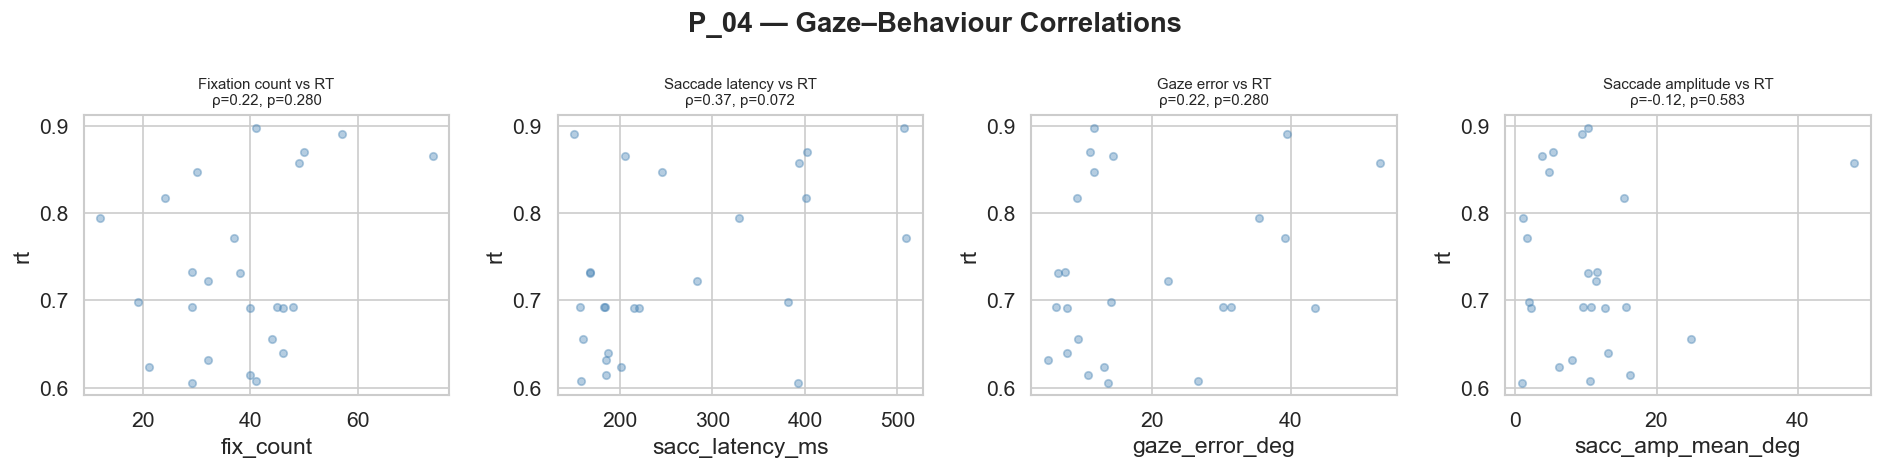

In [14]:
if GAZE_METRICS_CSV and Path(GAZE_METRICS_CSV).exists():
    gm = pd.read_csv(GAZE_METRICS_CSV)
    gm['trial_num'] = gm['trial_num'].astype(int)
    merged = df.merge(gm[['trial_num', 'fix_count', 'fix_dur_mean_ms',
                           'sacc_count', 'sacc_amp_mean_deg', 'sacc_latency_ms',
                           'gaze_error_deg', 'first_sacc_toward_target']],
                      on='trial_num', how='left')

    corr_pairs = [
        ('fix_count',           'rt', 'Fixation count vs RT'),
        ('sacc_latency_ms',     'rt', 'Saccade latency vs RT'),
        ('gaze_error_deg',      'rt', 'Gaze error vs RT'),
        ('sacc_amp_mean_deg',   'rt', 'Saccade amplitude vs RT'),
    ]
    fig, axes = plt.subplots(1, len(corr_pairs), figsize=(16, 4))
    valid_m = merged[merged['is_correct'] == 1].dropna()
    for ax, (xc, yc, title) in zip(axes, corr_pairs):
        if xc not in valid_m or yc not in valid_m:
            continue
        v = valid_m.dropna(subset=[xc, yc])
        ax.scatter(v[xc], v[yc], alpha=0.4, s=20, color='steelblue')
        if len(v) > 3:
            r, p = stats.spearmanr(v[xc], v[yc])
            ax.set_title(f'{title}\nρ={r:.2f}, p={p:.3f}', fontsize=9)
        ax.set_xlabel(xc)
        ax.set_ylabel(yc)
    plt.suptitle(f'{FOCAL_PARTICIPANT} — Gaze–Behaviour Correlations', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No gaze metrics CSV provided.')
    print(f'Set GAZE_METRICS_CSV = "<participant>_VISION_task_gaze_metrics.csv" to enable this section.')

---
## 14 Export Summary CSV

In [15]:
# ── Per-trial export ─────────────────────────────────────────────────────────
if 'hemifield' not in df.columns:
    df['hemifield'] = df['side'].map({'R':'Right','L':'Left'})

export_cols_trial = [
    'participant', 'trial_num', 'axis_deg', 'axis_label',
    'position_num', 'eccentricity_deg', 'side', 'hemifield',
    'shape', 'correct_key', 'response_key',
    'is_correct', 'rt',
]
out_trial = df[[c for c in export_cols_trial if c in df.columns]]
trial_path = f'{FOCAL_PARTICIPANT}_VISION_task_trials.csv'
out_trial.to_csv(trial_path, index=False)
print(f'Saved trial data  : {trial_path}  ({len(out_trial)} rows)')

# ── Summary export ────────────────────────────────────────────────────────────
m = core_metrics(df)
summary_row = {
    'participant'        : FOCAL_PARTICIPANT,
    'n_trials'           : m['n_trials'],
    'n_correct'          : m['n_correct'],
    'accuracy'           : round(m['accuracy'], 4),
    'pass_criterion'     : m['pass_criterion'],
    'rt_mean_s'          : round(m['rt_mean'], 4),
    'rt_sd_s'            : round(m['rt_sd'], 4),
    'rt_median_s'        : round(m['rt_median'], 4),
}
# Add breakdowns
for axis_lbl in ['Horizontal', 'Diagonal BL→TR', 'Diagonal TL→BR']:
    sub = df[df['axis_label'] == axis_lbl]
    key = axis_lbl.lower().replace(' ', '_').replace('→', '').replace('-', '')
    summary_row[f'accuracy_{key}'] = round(sub['is_correct'].mean(), 4) if len(sub) else np.nan
    summary_row[f'rt_mean_{key}']  = round(sub['rt'].mean(), 4) if len(sub) else np.nan
for hemi in ['Right', 'Left']:
    sub = df[df.get('hemifield', df['side'].map({'R':'Right','L':'Left'})) == hemi]
    summary_row[f'accuracy_{hemi.lower()}'] = round(sub['is_correct'].mean(), 4) if len(sub) else np.nan
    summary_row[f'rt_mean_{hemi.lower()}']  = round(sub['rt'].mean(), 4) if len(sub) else np.nan

summary_df = pd.DataFrame([summary_row])
summary_path = f'{FOCAL_PARTICIPANT}_VISION_task_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved summary     : {summary_path}')
summary_df.T

Saved trial data  : P_04_VISION_task_trials.csv  (42 rows)
Saved summary     : P_04_VISION_task_summary.csv


,0
participant,P_04
n_trials,42
n_correct,42
accuracy,1.0
pass_criterion,True
rt_mean_s,0.7468
rt_sd_s,0.1677
rt_median_s,0.711
accuracy_horizontal,1.0
rt_mean_horizontal,0.7692
